In [1]:
import pandas as pd
import spacy
import re
import matplotlib.pyplot as plt

from collections import Counter

In [2]:
amazon_alexa = pd.read_csv(r'data/amazon_alexa.tsv', sep='\t')
print(amazon_alexa)

      rating       date         variation  \
0          5  31-Jul-18  Charcoal Fabric    
1          5  31-Jul-18  Charcoal Fabric    
2          4  31-Jul-18    Walnut Finish    
3          5  31-Jul-18  Charcoal Fabric    
4          5  31-Jul-18  Charcoal Fabric    
...      ...        ...               ...   
3145       5  30-Jul-18        Black  Dot   
3146       5  30-Jul-18        Black  Dot   
3147       5  30-Jul-18        Black  Dot   
3148       5  30-Jul-18        White  Dot   
3149       4  29-Jul-18        Black  Dot   

                                       verified_reviews  feedback  
0                                         Love my Echo!         1  
1                                             Loved it!         1  
2     Sometimes while playing a game, you can answer...         1  
3     I have had a lot of fun with this thing. My 4 ...         1  
4                                                 Music         1  
...                                                

In [3]:
nlp_model = spacy.load("en_core_web_sm")

verified_reviews = amazon_alexa['verified_reviews']

cleaned_reviews = (
    verified_reviews.astype(str)
    .apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
    .apply(lambda x: re.sub(r'\s+', ' ', x).strip())
    .str.lower()
)

print(cleaned_reviews.head())

0                                         love my echo
1                                             loved it
2    sometimes while playing a game you can answer ...
3    i have had a lot of fun with this thing my yr ...
4                                                music
Name: verified_reviews, dtype: object


In [4]:
for review in cleaned_reviews[:5]:
    doc = nlp_model(review)

    # Token inspection (optional)
    print("Original tokens:")
    for token in doc[:5]:
        print(token.text, token.pos_, token.dep_, token.is_stop)

    # Remove stopwords, punctuation, numbers; then lemmatize
    lemmatized_tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and token.is_alpha
    ]

    print("Cleaned + lemmatized tokens:", lemmatized_tokens)
    print("Total tokens:", len(doc))
    print("Filtered tokens:", len(lemmatized_tokens))
    print("---")

Original tokens:
love VERB ROOT False
my PRON poss True
echo NOUN dobj False
Cleaned + lemmatized tokens: ['love', 'echo']
Total tokens: 3
Filtered tokens: 2
---
Original tokens:
loved VERB ROOT False
it PRON dobj True
Cleaned + lemmatized tokens: ['love']
Total tokens: 2
Filtered tokens: 1
---
Original tokens:
sometimes ADV advmod True
while SCONJ mark True
playing VERB advcl False
a DET det True
game NOUN dobj False
Cleaned + lemmatized tokens: ['play', 'game', 'answer', 'question', 'correctly', 'alexa', 'say', 'get', 'wrong', 'answer', 'like', 'able', 'turn', 'light', 'away', 'home']
Total tokens: 38
Filtered tokens: 16
---
Original tokens:
i PRON nsubj True
have AUX aux True
had VERB ccomp True
a DET det True
lot NOUN dobj False
Cleaned + lemmatized tokens: ['lot', 'fun', 'thing', 'yr', 'old', 'learn', 'dinosaur', 'control', 'light', 'play', 'game', 'like', 'category', 'nice', 'sound', 'play', 'music']
Total tokens: 33
Filtered tokens: 17
---
Original tokens:
music NOUN ROOT False


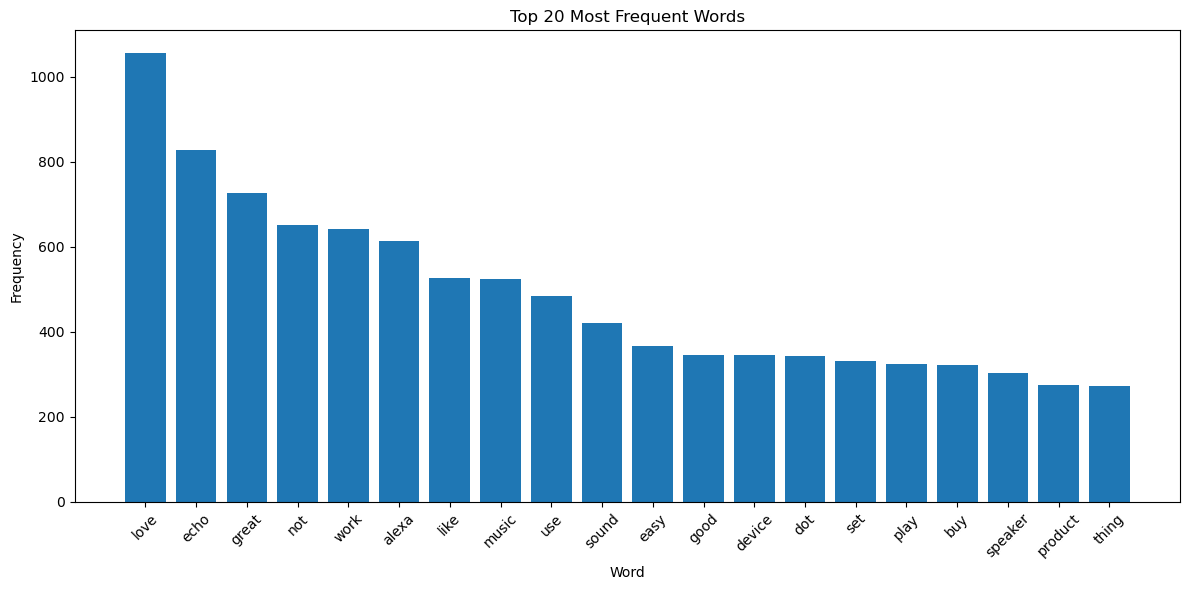

In [5]:
all_tokens = []

for review in cleaned_reviews:
    doc = nlp_model(review)
    tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop and token.is_alpha
    ]
    all_tokens.extend(tokens)


word_freq = Counter(all_tokens)
top_20 = word_freq.most_common(20)

# Separate words and frequencies for plotting
words, freqs = zip(*top_20)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(words, freqs)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()